Environment Dependencies Installs.

In [1]:
!pip install retina-face tensorflow tf-keras -q
print("Dependencies ready.")

Dependencies ready.


Cell 1 - Extraction + Folder Structure Diagnosis.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION — CELL 1
# Unzip + Structure Diagnostic
#
# Upload all 8 unknown domain zips to SageMaker before running this cell.
# Recommended upload path: /home/ec2-user/SageMaker/cross_dataset/zips/
#
# This cell:
#   1. Finds and extracts all zips in the upload directory
#   2. Maps the full folder structure of each extracted method
#   3. Reports image counts, formats, nesting depth, and real/fake split
#   4. Flags any method with insufficient images for the evaluation
#
# Expected methods (8 total — e4e excluded due to corrupted zip):
#   CollabDiff, deepfacelab, heygen, MidJourney,
#   stargan, starganv2, styleclip, whichfaceisreal
# ══════════════════════════════════════════════════════════════════════════════

import os
import zipfile
from pathlib import Path
from collections import defaultdict

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

ZIP_UPLOAD_DIR = "/home/ec2-user/SageMaker/cross_dataset/zips"
EXTRACT_BASE   = "/home/ec2-user/SageMaker/cross_dataset/extracted"
IMG_EXTS       = {".jpg", ".jpeg", ".png", ".webp"}

# Minimum images per class (real or fake) to be considered usable for evaluation
MIN_IMAGES_PER_CLASS = 50

os.makedirs(ZIP_UPLOAD_DIR, exist_ok=True)
os.makedirs(EXTRACT_BASE,   exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOCATE ZIPS
# ══════════════════════════════════════════════════════════════════════════════

zip_files = sorted(Path(ZIP_UPLOAD_DIR).glob("*.zip"))

if not zip_files:
    raise RuntimeError(
        f"No zip files found in {ZIP_UPLOAD_DIR}.\n"
        f"Upload your 8 zips to that directory first."
    )

print(f"Found {len(zip_files)} zip(s):\n")
for zp in zip_files:
    size_mb = zp.stat().st_size / (1024 ** 2)
    print(f"  {zp.name:<35} {size_mb:>8.1f} MB")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — EXTRACT
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'=' * 70}")
print("  EXTRACTING")
print(f"{'=' * 70}\n")

for zp in zip_files:
    extract_to = Path(EXTRACT_BASE) / zp.stem
    if extract_to.exists() and any(extract_to.iterdir()):
        print(f"  Already extracted: {zp.name} — skipping")
        continue
    extract_to.mkdir(parents=True, exist_ok=True)
    print(f"  Extracting: {zp.name} ...")
    try:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(extract_to)
        print(f"  Done → {extract_to}")
    except zipfile.BadZipFile as e:
        print(f"  ERROR: {zp.name} is corrupted and could not be extracted.")
        print(f"  Reason: {e}")
        print(f"  Skipping this method.\n")
        continue

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — STRUCTURE MAP
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'=' * 70}")
print("  STRUCTURE MAP")
print(f"{'=' * 70}")

method_dirs = sorted([
    d for d in Path(EXTRACT_BASE).iterdir()
    if d.is_dir() and any(d.rglob("*"))
])

grand_fake  = 0
grand_real  = 0
usable      = []
needs_review = []

for method_dir in method_dirs:
    print(f"\n  ── {method_dir.name} ──")
    print(f"  Root: {method_dir}")

    total_imgs     = 0
    format_counts  = defaultdict(int)
    top_level_map  = defaultdict(int)   # top-level subfolder → image count
    max_depth      = 0
    real_count     = 0
    fake_count     = 0

    # First pass — collect structural metadata
    for img_path in sorted(method_dir.rglob("*")):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        total_imgs += 1
        format_counts[img_path.suffix.lower()] += 1
        rel_parts  = img_path.relative_to(method_dir).parts
        depth      = len(rel_parts)
        max_depth  = max(max_depth, depth)
        top        = rel_parts[0] if depth > 1 else "(root)"
        top_level_map[top] += 1

    # Collect all unique folder names across all levels for classification audit
    all_folder_names = set()
    for p in method_dir.rglob("*"):
        if p.is_dir():
            all_folder_names.add(p.name.lower())

    # Known aliases for real and fake folders across different dataset conventions
    REAL_ALIASES = {
        "real", "reals", "original", "originals", "0_real",
        "genuine", "pristine", "authentic"
    }
    FAKE_ALIASES = {
        "fake", "fakes", "fake_images", "synthetics", "manipulated",
        "altered", "generated", "1_fake", "deepfake", "tampered"
    }

    detected_real_folders = sorted(all_folder_names & REAL_ALIASES)
    detected_fake_folders = sorted(all_folder_names & FAKE_ALIASES)
    unresolved_folders    = sorted(
        all_folder_names - REAL_ALIASES - FAKE_ALIASES - {"frames"}
    )

    # Count images per resolved class
    for img_path in sorted(method_dir.rglob("*")):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        parts_lower = [p.lower() for p in img_path.relative_to(method_dir).parts]
        if any(r in parts_lower for r in REAL_ALIASES):
            real_count += 1
        elif any(f in parts_lower for f in FAKE_ALIASES):
            fake_count += 1

    print(f"  Total images   : {total_imgs:,}")
    print(f"  Real images    : {real_count:,}")
    print(f"  Fake images    : {fake_count:,}")
    print(f"  Unclassified   : {total_imgs - real_count - fake_count:,}")
    print(f"  Max depth      : {max_depth} level(s) below method root")
    print(f"  Formats        : {dict(format_counts)}")
    print(f"  Folders → real : {detected_real_folders or ['none detected']}")
    print(f"  Folders → fake : {detected_fake_folders or ['none detected']}")
    print(f"  Unresolved     : {unresolved_folders or ['none — fully mapped']}")
    print(f"  Top-level subfolders:")
    for subfolder, count in sorted(top_level_map.items()):
        print(f"    {subfolder:<35} {count:>6,} images")

    grand_real += real_count
    grand_fake += fake_count

    # Usability flag
    if real_count >= MIN_IMAGES_PER_CLASS and fake_count >= MIN_IMAGES_PER_CLASS:
        usable.append(method_dir.name)
        print(f"  Status         : USABLE ✓")
    else:
        needs_review.append((method_dir.name, real_count, fake_count))
        print(f"  Status         : REVIEW NEEDED "
              f"(real={real_count}, fake={fake_count}, min={MIN_IMAGES_PER_CLASS})")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'=' * 70}")
print("  DIAGNOSTIC SUMMARY")
print(f"{'=' * 70}")
print(f"  Methods extracted  : {len(method_dirs)}")
print(f"  Methods usable     : {len(usable)}")
print(f"  Grand total real   : {grand_real:,}")
print(f"  Grand total fake   : {grand_fake:,}")
print(f"  Grand total images : {grand_real + grand_fake:,}")

if needs_review:
    print(f"\n  Methods needing review (low image count):")
    for name, r, f in needs_review:
        print(f"    {name:<25}  real={r}  fake={f}")
else:
    print(f"\n  All methods passed minimum image count threshold.")

print(f"\n  Proceed to Cell 2 (RetinaFace crop pipeline) once you have")
print(f"  reviewed the structure above and confirmed folder paths.")
print(f"{'=' * 70}\n")

Found 8 zip(s):

  CollabDiff.zip                         337.8 MB
  MidJourney.zip                        1124.7 MB
  deepfacelab.zip                        352.7 MB
  heygen.zip                            2532.5 MB
  stargan.zip                             32.6 MB
  starganv2.zip                           36.6 MB
  styleclip.zip                          228.5 MB
  whichfaceisreal.zip                    781.2 MB

  EXTRACTING

  Extracting: CollabDiff.zip ...
  Done → /home/ec2-user/SageMaker/cross_dataset/extracted/CollabDiff
  Extracting: MidJourney.zip ...
  Done → /home/ec2-user/SageMaker/cross_dataset/extracted/MidJourney
  Extracting: deepfacelab.zip ...
  Done → /home/ec2-user/SageMaker/cross_dataset/extracted/deepfacelab
  Extracting: heygen.zip ...
  Done → /home/ec2-user/SageMaker/cross_dataset/extracted/heygen
  Extracting: stargan.zip ...
  Done → /home/ec2-user/SageMaker/cross_dataset/extracted/stargan
  Extracting: starganv2.zip ...
  Done → /home/ec2-user/SageMaker/cros

In [2]:
!find /home/ec2-user/SageMaker/cross_dataset/extracted -name "__MACOSX" -type d -exec rm -rf {} + 2>/dev/null
!find /home/ec2-user/SageMaker/cross_dataset/extracted -name "._*" -delete 2>/dev/null
print("Cleaned.")

Cleaned.


Cell 2 - RetinaFace + Data Funnel.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION — CELL 2
# RetinaFace Crop Pipeline
#
# Replicates the exact preprocessing chain used during training:
#   confidence ≥ 0.90 → largest face → 20px padding →
#   blur filter → BGR→RGB → bicubic 260×260 → JPEG q95
#
# Input  : cross_dataset/extracted/  (8 method folders from Cell 1)
# Output : cross_dataset/cropped/real/  and  cross_dataset/cropped/fake/
#
# Sampling strategy:
#   - Up to MAX_PER_METHOD_FAKE fake images per method
#   - Equal number of real images per method (balanced)
#   - Methods with fewer images contribute everything they have
#   - All output is flat — no per-method subfolders
#
# Target: ~3,200 fake + ~3,200 real = ~6,400 total (before RetinaFace dropout)
# ══════════════════════════════════════════════════════════════════════════════

import os

# TF env vars must be set before RetinaFace import
os.environ["TF_USE_LEGACY_KERAS"]   = "1"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import cv2
import random
import warnings
import numpy as np
from pathlib import Path
from PIL import Image
from retinaface import RetinaFace
from tqdm import tqdm

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — matches training preprocessing exactly
# ══════════════════════════════════════════════════════════════════════════════

EXTRACT_BASE  = "/home/ec2-user/SageMaker/cross_dataset/extracted"
CROPPED_BASE  = "/home/ec2-user/SageMaker/cross_dataset/cropped"
REAL_OUT_DIR  = os.path.join(CROPPED_BASE, "real")
FAKE_OUT_DIR  = os.path.join(CROPPED_BASE, "fake")

IMG_EXTS      = {".jpg", ".jpeg", ".png", ".webp"}

# RetinaFace thresholds — identical to training pipeline
CONFIDENCE_THRESHOLD = 0.90
MIN_FACE_SIZE        = 50       # pixels, width and height
BLUR_THRESHOLD       = 12.0    # Laplacian variance — rejects blurry crops
PADDING              = 20      # pixels added around detected bounding box
RESIZE_TARGET        = (260, 260)
JPEG_QUALITY         = 95

# Sampling
MAX_PER_METHOD_FAKE  = 400     # max fake images to attempt per method
                                # reals matched to actual fake yield per method

# Folder name aliases — must match Cell 1 classification sets exactly
REAL_ALIASES = {
    "real", "reals", "original", "originals", "0_real",
    "genuine", "pristine", "authentic"
}
FAKE_ALIASES = {
    "fake", "fakes", "fake_images", "synthetics", "manipulated",
    "altered", "generated", "1_fake", "deepfake", "tampered"
}

# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(REAL_OUT_DIR, exist_ok=True)
os.makedirs(FAKE_OUT_DIR, exist_ok=True)

method_dirs = sorted([
    d for d in Path(EXTRACT_BASE).iterdir()
    if d.is_dir() and any(d.rglob("*"))
])

if not method_dirs:
    raise RuntimeError(
        f"No extracted method folders found in {EXTRACT_BASE}.\n"
        f"Run Cell 1 first."
    )

print(f"Found {len(method_dirs)} extracted method(s):")
for m in method_dirs:
    print(f"  {m.name}")

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def classify_image_path(img_path, method_root):
    """Return 'real', 'fake', or None based on folder name aliases."""
    parts_lower = [p.lower() for p in img_path.relative_to(method_root).parts]
    if any(p in REAL_ALIASES for p in parts_lower):
        return "real"
    if any(p in FAKE_ALIASES for p in parts_lower):
        return "fake"
    return None


def collect_images(method_dir):
    """
    Recursively collect all image paths under a method folder.
    Returns dict: {'real': [...], 'fake': [...], 'unclassified': [...]}
    """
    buckets = {"real": [], "fake": [], "unclassified": []}
    for img_path in sorted(method_dir.rglob("*")):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        label = classify_image_path(img_path, method_dir)
        if label:
            buckets[label].append(img_path)
        else:
            buckets["unclassified"].append(img_path)
    return buckets


def extract_face(img_path):
    """
    Run RetinaFace on one image. Returns cropped PIL Image or None.
    Replicates exact training preprocessing chain:
      - Largest face by area selected
      - confidence ≥ CONFIDENCE_THRESHOLD
      - min face size MIN_FACE_SIZE px
      - blur filter BLUR_THRESHOLD
      - 20px padding
      - bicubic resize to 260×260
    """
    # Load BGR (OpenCV native format — required by RetinaFace)
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None

    h, w = img_bgr.shape[:2]

    try:
        detections = RetinaFace.detect_faces(img_bgr)
    except Exception:
        return None

    if not isinstance(detections, dict) or len(detections) == 0:
        return None

    # Select largest face by bounding box area
    best_face   = None
    best_area   = 0

    for face_key, face_data in detections.items():
        score = face_data.get("score", 0)
        if score < CONFIDENCE_THRESHOLD:
            continue

        x1, y1, x2, y2 = face_data["facial_area"]
        fw = x2 - x1
        fh = y2 - y1

        if fw < MIN_FACE_SIZE or fh < MIN_FACE_SIZE:
            continue

        area = fw * fh
        if area > best_area:
            best_area = area
            best_face = (x1, y1, x2, y2)

    if best_face is None:
        return None

    x1, y1, x2, y2 = best_face

    # Apply padding (clamped to image boundaries)
    x1 = max(0, x1 - PADDING)
    y1 = max(0, y1 - PADDING)
    x2 = min(w, x2 + PADDING)
    y2 = min(h, y2 + PADDING)

    crop_bgr = img_bgr[y1:y2, x1:x2]
    if crop_bgr.size == 0:
        return None

    # Blur filter — reject low-quality crops
    gray      = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    if blur_score < BLUR_THRESHOLD:
        return None

    # BGR → RGB → PIL → bicubic resize
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img  = Image.fromarray(crop_rgb)
    pil_img  = pil_img.resize(RESIZE_TARGET, Image.BICUBIC)

    return pil_img


def save_face(pil_img, out_dir, method_name, idx):
    """Save face crop as JPEG. Returns saved path."""
    filename  = f"{method_name}_{idx:05d}.jpg"
    out_path  = os.path.join(out_dir, filename)
    pil_img.save(out_path, "JPEG", quality=JPEG_QUALITY)
    return out_path

# ══════════════════════════════════════════════════════════════════════════════
# MAIN EXTRACTION LOOP
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  RETINAFACE CROP PIPELINE")
print("=" * 70 + "\n")

summary = []   # per-method results for final report

for method_dir in method_dirs:
    method_name = method_dir.name
    print(f"\n  [{method_name}]")

    # Collect all images classified by real/fake
    buckets = collect_images(method_dir)
    n_real_src  = len(buckets["real"])
    n_fake_src  = len(buckets["fake"])
    n_unclass   = len(buckets["unclassified"])

    print(f"  Source images — real: {n_real_src:,}  fake: {n_fake_src:,}  "
          f"unclassified: {n_unclass:,}")

    if n_fake_src == 0 and n_real_src == 0:
        print(f"  WARNING: No classifiable images found. Skipping.")
        summary.append({
            "method": method_name, "fake_src": 0, "real_src": 0,
            "fake_saved": 0, "real_saved": 0, "status": "SKIPPED"
        })
        continue

    # Deterministic shuffle before sampling
    random.shuffle(buckets["fake"])
    random.shuffle(buckets["real"])

    # Sample up to MAX_PER_METHOD_FAKE fakes
    fake_candidates = buckets["fake"][:MAX_PER_METHOD_FAKE]

    # ── Process fakes ──────────────────────────────────────────────────────
    fake_saved = 0
    print(f"  Processing {len(fake_candidates)} fake candidates...")

    for img_path in tqdm(fake_candidates, desc=f"  {method_name} fake", leave=False):
        face = extract_face(img_path)
        if face is None:
            continue
        save_face(face, FAKE_OUT_DIR, method_name, fake_saved)
        fake_saved += 1

    print(f"  Fake faces saved: {fake_saved}")

    # ── Process reals — match to fake yield ───────────────────────────────
    real_candidates = buckets["real"][:fake_saved * 2]   # oversample to hit target
    real_saved = 0
    print(f"  Processing real candidates to match {fake_saved} fakes...")

    for img_path in tqdm(real_candidates, desc=f"  {method_name} real", leave=False):
        if real_saved >= fake_saved:
            break
        face = extract_face(img_path)
        if face is None:
            continue
        save_face(face, REAL_OUT_DIR, method_name, real_saved)
        real_saved += 1

    print(f"  Real faces saved: {real_saved}")

    status = "OK" if fake_saved > 0 and real_saved > 0 else "LOW YIELD"
    summary.append({
        "method": method_name,
        "fake_src": n_fake_src, "real_src": n_real_src,
        "fake_saved": fake_saved, "real_saved": real_saved,
        "status": status
    })

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  CROP PIPELINE SUMMARY")
print("=" * 70)
print(f"\n  {'Method':<20} {'Fake src':>9} {'Real src':>9} "
      f"{'Fake saved':>11} {'Real saved':>11}  Status")
print(f"  {'-'*20}  {'-'*9}  {'-'*9}  {'-'*11}  {'-'*11}  {'-'*10}")

total_fake_saved = 0
total_real_saved = 0

for row in summary:
    print(f"  {row['method']:<20} {row['fake_src']:>9,} {row['real_src']:>9,} "
          f"{row['fake_saved']:>11,} {row['real_saved']:>11,}  {row['status']}")
    total_fake_saved += row["fake_saved"]
    total_real_saved += row["real_saved"]

print(f"\n  Total fake faces saved : {total_fake_saved:,}")
print(f"  Total real faces saved : {total_real_saved:,}")
print(f"  Grand total            : {total_fake_saved + total_real_saved:,}")
print(f"\n  Output:")
print(f"    {FAKE_OUT_DIR}")
print(f"    {REAL_OUT_DIR}")
print(f"\n  Proceed to Cell 3 (inference + metrics + Grad-CAM).")
print("=" * 70 + "\n")

I0000 00:00:1776915242.466031   60751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776915242.529198   60751 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776915244.061532   60751 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 8 extracted method(s):
  CollabDiff
  MidJourney
  deepfacelab
  heygen
  stargan
  starganv2
  styleclip
  whichfaceisreal

  RETINAFACE CROP PIPELINE


  [CollabDiff]
  Source images — real: 1,000  fake: 1,000  unclassified: 0
  Processing 400 fake candidates...


  CollabDiff fake:   0%|          | 0/400 [00:00<?, ?it/s]W0000 00:00:1776915258.081991   60751 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1776915258.082921   60751 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /home/ec2-user/.deepface/weights/retinaface.h5


26-04-23 03:34:20 - Directory /home/ec2-user/.deepface created
26-04-23 03:34:20 - Directory /home/ec2-user/.deepface/weights created
26-04-23 03:34:20 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5



  0%|          | 0.00/119M [00:00<?, ?B/s]
 18%|█▊        | 21.5M/119M [00:00<00:00, 179MB/s]
 45%|████▍     | 53.0M/119M [00:00<00:00, 234MB/s]
 65%|██████▍   | 76.5M/119M [00:00<00:00, 231MB/s]
100%|██████████| 119M/119M [00:00<00:00, 238MB/s] 
I0000 00:00:1776915262.861452   61013 cuda_dnn.cc:461] Loaded cuDNN version 91002
                                                                    

...

  Real faces saved: 400

  [styleclip]
  Source images — real: 1,000  fake: 2,824  unclassified: 0
  Processing 400 fake candidates...


  Fake faces saved: 389
  Processing real candidates to match 389 fakes...


  Real faces saved: 389

  [whichfaceisreal]
  Source images — real: 1,000  fake: 1,001  unclassified: 0
  Processing 400 fake candidates...


  Fake faces saved: 400
  Processing real candidates to match 400 fakes...


  Real faces saved: 400

  CROP PIPELINE SUMMARY

  Method                Fake src  Real src  Fake saved  Real saved  Status
  --------------------  ---------  ---------  -----------  -----------  ----------
  CollabDiff               1,000     1,000         400         400  OK
  MidJourney                 635     1,000         371         371  OK
  deepfacelab              3,122     1,547         351         351  OK
  heygen                   1,605     7,536         400         400  OK
  stargan                  1,984     1,984         397         397  OK
  starganv2                2,000     2,000         400         400  OK
  styleclip                2,824     1,000         389         389  OK
  whichfaceisreal          1,001     1,000         400         400  OK

  Total fake faces saved : 3,108
  Total real faces saved : 3,108
  Grand total            : 6,216

  Output:
    /home/ec2-user/SageMaker/cross_dataset/cropped/fake
    /home/ec2-user/SageMaker/cross_dataset/cropped/real



Cell 3 - ENB2 Best Epoch Checkpoint Load from S3 and Model Setup.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION — CELL 3
# Model Setup — Download Run 5 Checkpoint + EfficientNet-B2 Architecture
#
# Downloads best_effnetb2.pth from S3 and loads it into the model.
# This cell must run before Cell 4 (inference + metrics + Grad-CAM).
#
# S3 source:
#   s3://deepfake-d-100k-dataset-tw26/models/Run5/best_effnetb2.pth
# ══════════════════════════════════════════════════════════════════════════════
import os
import boto3
import torch
import torch.nn as nn
from torchvision import models

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
S3_BUCKET      = "deepfake-d-100k-dataset-tw26"
S3_CHECKPOINT  = "models/Run5/best_effnetb2.pth"
LOCAL_CKPT_DIR = "/home/ec2-user/SageMaker/checkpoints"
LOCAL_CKPT     = os.path.join(LOCAL_CKPT_DIR, "run5_best_effnetb2.pth")

# ══════════════════════════════════════════════════════════════════════════════
# DEVICE
# ══════════════════════════════════════════════════════════════════════════════
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device.type.upper()}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DOWNLOAD CHECKPOINT FROM S3
# ══════════════════════════════════════════════════════════════════════════════
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

if os.path.exists(LOCAL_CKPT) and os.path.getsize(LOCAL_CKPT) > 1024 * 1024:
    print(f"\nCheckpoint already on EBS: {LOCAL_CKPT}")
else:
    _s3     = boto3.client("s3")
    size_mb = _s3.head_object(
        Bucket=S3_BUCKET, Key=S3_CHECKPOINT
    )["ContentLength"] / (1024 ** 2)
    print(f"\nDownloading checkpoint ({size_mb:.1f} MB) from S3...")
    _s3.download_file(S3_BUCKET, S3_CHECKPOINT, LOCAL_CKPT)
    print(f"Saved -> {LOCAL_CKPT}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — BUILD EFFICIENTNET-B2 ARCHITECTURE
# Must match training Cell 2 exactly:
#   - EfficientNet-B2 pretrained weights (replaced by checkpoint)
#   - Head: Dropout(0.3) → Linear(1408, 2)
#   - Label convention: 0 = Fake, 1 = Real
# ══════════════════════════════════════════════════════════════════════════════
print("\nBuilding EfficientNet-B2 architecture...")
model = models.efficientnet_b2(weights=None)
in_features      = model.classifier[1].in_features   # 1408
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 2)
)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — LOAD CHECKPOINT
# ══════════════════════════════════════════════════════════════════════════════
print(f"Loading checkpoint: {LOCAL_CKPT}")
checkpoint = torch.load(LOCAL_CKPT, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

# Unfreeze all parameters — required for Grad-CAM backward pass to reach
# model.features. load_state_dict restores weights only, not requires_grad
# flags. Without this, score.backward() stops at the classifier head and
# the hooks in model.features never fire.
for param in model.parameters():
    param.requires_grad = True

model.to(device)
model.eval()

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — VERIFY
# ══════════════════════════════════════════════════════════════════════════════
print("\nRunning forward pass sanity check...")
with torch.no_grad():
    dummy = torch.randn(2, 3, 260, 260).to(device)
    out   = model(dummy)
assert out.shape == (2, 2), \
    f"Unexpected output shape: {out.shape}. Expected (2, 2)."
print(f"  Input  : {tuple(dummy.shape)}")
print(f"  Output : {tuple(out.shape)}  — 2 classes confirmed (0=Fake, 1=Real)")

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "=" * 60)
print("  MODEL READY")
print("=" * 60)
print(f"  Architecture  : EfficientNet-B2")
print(f"  Head          : Dropout(0.3) -> Linear(1408, 2)")
print(f"  Checkpoint    : run5_best_effnetb2.pth")
print(f"  Saved epoch   : {checkpoint['epoch']}")
print(f"  Best val loss : {checkpoint['best_val_loss']:.4f}")
print(f"  Best val acc  : {checkpoint['best_val_acc']:.4f}")
print(f"  Best val AUC  : {checkpoint['best_val_auc']:.4f}")
print(f"  Total params  : {total_params:,}")
print(f"  All unfrozen  : {trainable_params == total_params}")
print(f"  Device        : {device.type.upper()}")
print("=" * 60)
print("\n  model and device are now in scope. Proceed to Cell 4.")

Device : CUDA
GPU    : NVIDIA L4
VRAM   : 22.0 GB

Saved -> /home/ec2-user/SageMaker/checkpoints/run5_best_effnetb2.pth

Building EfficientNet-B2 architecture...
Loading checkpoint: /home/ec2-user/SageMaker/checkpoints/run5_best_effnetb2.pth

Running forward pass sanity check...
  Input  : (2, 3, 260, 260)
  Output : (2, 2)  — 2 classes confirmed (0=Fake, 1=Real)

  MODEL READY
  Architecture  : EfficientNet-B2
  Head          : Dropout(0.3) -> Linear(1408, 2)
  Checkpoint    : run5_best_effnetb2.pth
  Saved epoch   : 19
  Best val loss : 0.1344
  Best val acc  : 0.9572
  Best val AUC  : 0.9917
  Total params  : 7,703,812
  All unfrozen  : True
  Device        : CUDA

  model and device are now in scope. Proceed to Cell 4.


Cell 4 - Inference / Metrics / Heatmaps.


  CROSS-DATASET EVALUATION — CELL 4

  Total images : 6,216  (real=3,108  fake=3,108)
  Methods      : 8  — ['CollabDiff', 'MidJourney', 'deepfacelab', 'heygen', 'stargan', 'starganv2', 'styleclip', 'whichfaceisreal']
  Batches      : 98

Running inference...

  AGGREGATE TEST RESULTS — ALL METHODS COMBINED
              precision    recall  f1-score   support

    Fake (0)     0.8345    0.4479    0.5829      3108
    Real (1)     0.6227    0.9112    0.7398      3108

    accuracy                         0.6795      6216
   macro avg     0.7286    0.6795    0.6614      6216
weighted avg     0.7286    0.6795    0.6614      6216

  Accuracy : 0.6795
  F1 Score : 0.7398
  ROC-AUC  : 0.7150

  PER-METHOD BREAKDOWN

  Method                     N     Acc      F1      AUC   Fake det%   Real det%
  ----------------------  -----  -------  -------  --------  ----------  ----------
  CollabDiff               800  0.8313  0.8525   0.9709       68.8%       97.5%
  MidJourney               742  0.

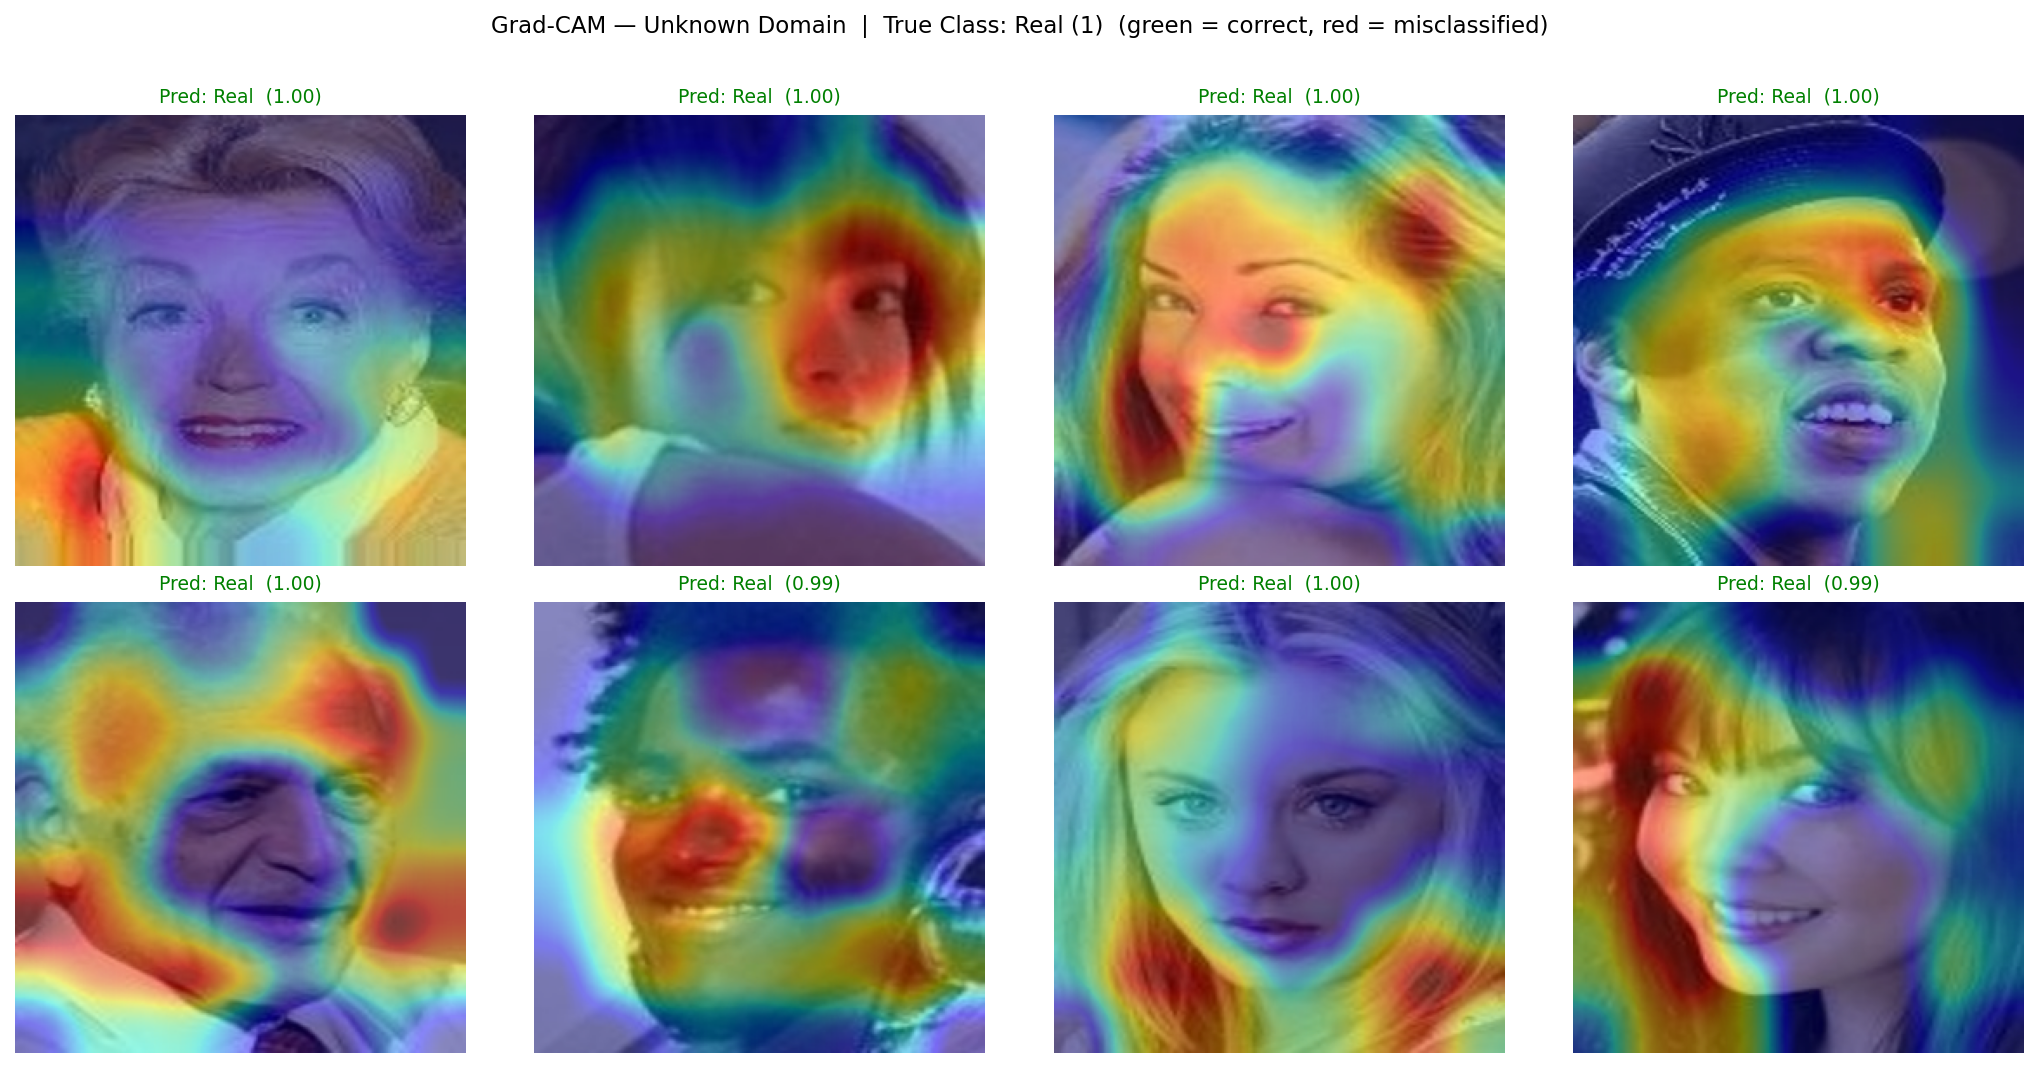

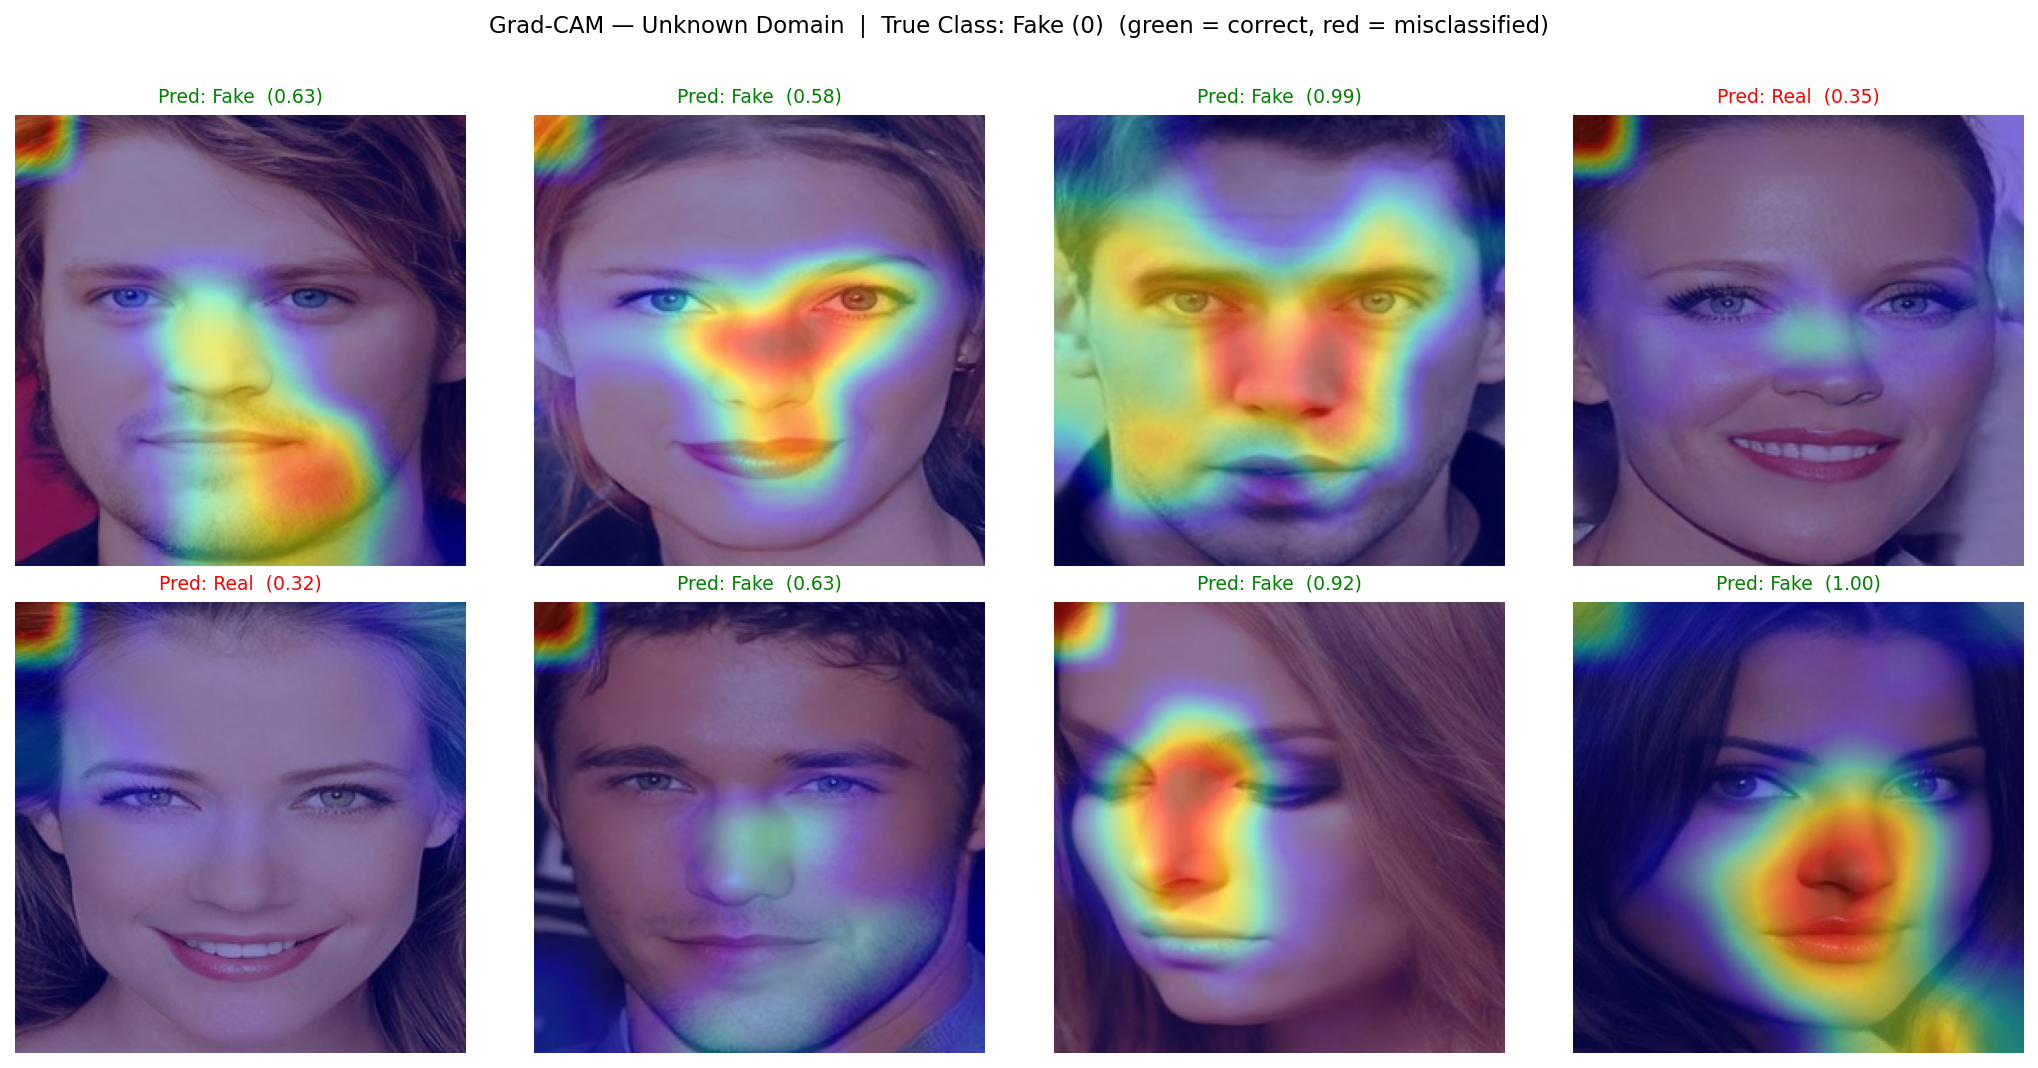

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION — CELL 4
# Inference + Metrics + Per-Method Breakdown + Grad-CAM
#
# Reads from cross_dataset/cropped/real/ and cross_dataset/cropped/fake/
# Filenames are methodname_00000.jpg so per-method breakdown is derived
# from the filename prefix — no folder reorganisation needed.
#
# Outputs:
#   - Classification report (precision, recall, F1)
#   - Confusion matrix + ROC curve
#   - Per-method AUC and accuracy table
#   - Confidence distribution plot
#   - Grad-CAM heatmaps (real and fake samples)
#
# Label convention (matches training pipeline):
#   0 = Fake   1 = Real
#
# Requires Cell 3 to have run (model and device in scope).
# ══════════════════════════════════════════════════════════════════════════════

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
    ConfusionMatrixDisplay,
)
from collections import defaultdict

SEED = globals().get("SEED", 42)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

CROPPED_BASE  = "/home/ec2-user/SageMaker/cross_dataset/cropped"
REAL_DIR      = os.path.join(CROPPED_BASE, "real")
FAKE_DIR      = os.path.join(CROPPED_BASE, "fake")

RESULTS_DIR   = "/home/ec2-user/SageMaker/cross_dataset/results"
GRADCAM_DIR   = os.path.join(RESULTS_DIR, "gradcam")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

BATCH_SIZE               = 64
NUM_WORKERS              = 4
GRADCAM_SAMPLES_PER_CLASS = 8
IMG_EXTS                 = {".jpg", ".jpeg", ".png", ".webp"}

# ══════════════════════════════════════════════════════════════════════════════
# DATASET — reads flat real/ and fake/ folders
# Extracts method name from filename prefix: methodname_00000.jpg
# ══════════════════════════════════════════════════════════════════════════════

val_test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CrossDataset(Dataset):
    """
    Loads all images from real_dir (label=1) and fake_dir (label=0).
    Method name extracted from filename prefix for per-method reporting.
    """

    def __init__(self, real_dir, fake_dir, transform=None):
        self.transform = transform
        self.samples   = []   # (path, label, method_name)

        for img_path in sorted(Path(real_dir).glob("*")):
            if img_path.suffix.lower() in IMG_EXTS:
                method = "_".join(img_path.stem.split("_")[:-1])
                self.samples.append((str(img_path), 1, method))

        for img_path in sorted(Path(fake_dir).glob("*")):
            if img_path.suffix.lower() in IMG_EXTS:
                method = "_".join(img_path.stem.split("_")[:-1])
                self.samples.append((str(img_path), 0, method))

        if not self.samples:
            raise RuntimeError(
                f"No images found in {real_dir} or {fake_dir}.\n"
                f"Run Cell 2 (RetinaFace) first."
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, method = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            return self.__getitem__((idx + 1) % len(self.samples))
        if self.transform:
            img = self.transform(img)
        return img, label, method


dataset    = CrossDataset(REAL_DIR, FAKE_DIR, transform=val_test_transform)
loader     = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)

n_real = sum(1 for _, lbl, _ in dataset.samples if lbl == 1)
n_fake = sum(1 for _, lbl, _ in dataset.samples if lbl == 0)
methods_present = sorted(set(m for _, _, m in dataset.samples))

print("\n" + "=" * 70)
print("  CROSS-DATASET EVALUATION — CELL 4")
print("=" * 70)
print(f"\n  Total images : {len(dataset):,}  (real={n_real:,}  fake={n_fake:,})")
print(f"  Methods      : {len(methods_present)}  — {methods_present}")
print(f"  Batches      : {len(loader):,}")

# ══════════════════════════════════════════════════════════════════════════════
# DEVICE CONSISTENCY CHECK
# ══════════════════════════════════════════════════════════════════════════════

assert next(model.parameters()).device.type == device.type, (
    f"Model is on {next(model.parameters()).device} but device is {device}. "
    f"Run Cell 3 first."
)

# ══════════════════════════════════════════════════════════════════════════════
# INFERENCE LOOP
# ══════════════════════════════════════════════════════════════════════════════

print("\nRunning inference...")

all_preds   = []
all_trues   = []
all_probs   = []
all_methods = []

with torch.inference_mode():
    for inputs, labels, methods in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            outputs = model(inputs)

        if outputs.ndim != 2 or outputs.size(1) != 2:
            raise ValueError(f"Unexpected output shape: {tuple(outputs.shape)}")

        probs = F.softmax(outputs.float(), dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_trues.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_methods.extend(list(methods))

all_preds   = np.array(all_preds)
all_trues   = np.array(all_trues)
all_probs   = np.array(all_probs)
all_methods = np.array(all_methods)

if len(all_trues) == 0:
    raise RuntimeError("Inference produced zero samples. Check dataset paths.")

# ══════════════════════════════════════════════════════════════════════════════
# AGGREGATE METRICS
# ══════════════════════════════════════════════════════════════════════════════

acc = accuracy_score(all_trues, all_preds)
f1  = f1_score(all_trues, all_preds, zero_division=0)
auc = roc_auc_score(all_trues, all_probs) if len(np.unique(all_trues)) > 1 else None

print("\n" + "=" * 70)
print("  AGGREGATE TEST RESULTS — ALL METHODS COMBINED")
print("=" * 70)
print(classification_report(
    all_trues, all_preds,
    target_names=["Fake (0)", "Real (1)"],
    digits=4,
    zero_division=0,
))
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {auc:.4f}" if auc is not None else "  ROC-AUC  : undefined")

# ══════════════════════════════════════════════════════════════════════════════
# PER-METHOD BREAKDOWN
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  PER-METHOD BREAKDOWN")
print("=" * 70)
print(f"\n  {'Method':<22} {'N':>5} {'Acc':>7} {'F1':>7} {'AUC':>8}  "
      f"{'Fake det%':>10}  {'Real det%':>10}")
print(f"  {'-'*22}  {'-'*5}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*10}  {'-'*10}")

method_results = {}

for method in sorted(set(all_methods)):
    mask   = all_methods == method
    m_true = all_trues[mask]
    m_pred = all_preds[mask]
    m_prob = all_probs[mask]

    if len(m_true) == 0:
        continue

    m_acc = accuracy_score(m_true, m_pred)
    m_f1  = f1_score(m_true, m_pred, zero_division=0)
    m_auc = roc_auc_score(m_true, m_prob) if len(np.unique(m_true)) > 1 else None

    # Detection rates per class
    fake_mask    = m_true == 0
    real_mask    = m_true == 1
    fake_det_pct = (m_pred[fake_mask] == 0).mean() * 100 if fake_mask.sum() > 0 else float("nan")
    real_det_pct = (m_pred[real_mask] == 1).mean() * 100 if real_mask.sum() > 0 else float("nan")

    auc_str = f"{m_auc:.4f}" if m_auc is not None else "  N/A  "
    print(f"  {method:<22} {len(m_true):>5,} {m_acc:>7.4f} {m_f1:>7.4f} {auc_str:>8}  "
          f"{fake_det_pct:>9.1f}%  {real_det_pct:>9.1f}%")

    method_results[method] = {
        "n": len(m_true), "acc": m_acc, "f1": m_f1,
        "auc": m_auc, "fake_det": fake_det_pct, "real_det": real_det_pct
    }

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS — CONFUSION MATRIX + ROC CURVE + CONFIDENCE DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Confusion matrix
cm   = confusion_matrix(all_trues, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake (0)", "Real (1)"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Unknown Domain", fontsize=12)

# ROC curve
if auc is not None:
    fpr, tpr, _ = roc_curve(all_trues, all_probs)
    axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve — Unknown Domain", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "ROC curve unavailable", ha="center", va="center")
    axes[1].set_title("ROC Curve", fontsize=12)

# Confidence distribution — shows how certain model is on unseen methods
real_probs = all_probs[all_trues == 1]
fake_probs = all_probs[all_trues == 0]
axes[2].hist(real_probs, bins=40, alpha=0.6, color="steelblue",  label="True Real")
axes[2].hist(fake_probs, bins=40, alpha=0.6, color="tomato",     label="True Fake")
axes[2].axvline(0.5, color="black", linestyle="--", lw=1.2, label="Decision boundary")
axes[2].set_xlabel("P(Real) — Model Confidence")
axes[2].set_ylabel("Count")
axes[2].set_title("Confidence Distribution — Unknown Domain", fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
metrics_plot_path = os.path.join(RESULTS_DIR, "cross_dataset_metrics.png")
plt.savefig(metrics_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"\n  Metrics plot saved -> {metrics_plot_path}")

# ══════════════════════════════════════════════════════════════════════════════
# GRAD-CAM — same battle-tested implementation as training Cell 5
# ══════════════════════════════════════════════════════════════════════════════

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        self.gradients    = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.fwd_handle = self.target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(backward_hook)

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, input_tensor, class_idx):
        assert input_tensor.size(0) == 1, \
            f"GradCAM expects batch size 1, got {input_tensor.size(0)}"
        self.activations = None
        self.gradients   = None
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        output = self.model(input_tensor)
        score  = output[0, class_idx]
        score.backward(retain_graph=False)
        if self.gradients is None or self.activations is None:
            raise RuntimeError(
                "Grad-CAM hooks did not fire. Check target layer."
            )
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = F.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            return np.zeros_like(cam.cpu().numpy())
        return cam.cpu().numpy()


def overlay_heatmap(img_tensor, heatmap, alpha=0.45):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img  = (img * std + mean).clip(0, 1)
    heatmap_pil = Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
        (img.shape[1], img.shape[0]), Image.BICUBIC
    )
    heatmap_np  = np.array(heatmap_pil) / 255.0
    heatmap_rgb = plt.cm.jet(heatmap_np)[:, :, :3]
    overlaid    = (1 - alpha) * img + alpha * heatmap_rgb
    overlaid    = (overlaid.clip(0, 1) * 255).astype(np.uint8)
    return Image.fromarray(overlaid)


# Target last Conv2d in model.features
assert hasattr(model, "features"), "model.features not found — run Cell 3 first."
target_layer = None
for m in reversed(list(model.features.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
if target_layer is None:
    raise ValueError("No Conv2d found in model.features for Grad-CAM.")

print(f"\nGrad-CAM target layer: {target_layer.__class__.__name__} "
      f"(last Conv2d in model.features)")
gradcam = GradCAM(model, target_layer)
print("Generating Grad-CAM heatmaps...")

# Collect samples from the dataset tensors directly
samples_real = []
samples_fake = []

for img_tensor, label, _ in dataset:
    if label == 1 and len(samples_real) < GRADCAM_SAMPLES_PER_CLASS:
        samples_real.append(img_tensor)
    elif label == 0 and len(samples_fake) < GRADCAM_SAMPLES_PER_CLASS:
        samples_fake.append(img_tensor)
    if (len(samples_real) >= GRADCAM_SAMPLES_PER_CLASS and
            len(samples_fake) >= GRADCAM_SAMPLES_PER_CLASS):
        break


def generate_gradcam_grid(samples, class_name, class_idx, filename):
    n    = len(samples)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).flatten()
    for ax in axes:
        ax.axis("off")

    for i, img_tensor in enumerate(samples):
        inp = img_tensor.unsqueeze(0).to(device, dtype=torch.float32)
        with torch.enable_grad():
            with torch.amp.autocast("cuda", enabled=False):
                heatmap = gradcam.generate(inp, class_idx=class_idx)
        overlaid = overlay_heatmap(img_tensor, heatmap)
        with torch.inference_mode():
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(inp)
        prob     = F.softmax(logits.float(), dim=1)[0, class_idx].item()
        pred_cls = torch.argmax(logits, dim=1).item()
        pred_str = "Real" if pred_cls == 1 else "Fake"
        color    = "green" if pred_cls == class_idx else "red"
        axes[i].imshow(overlaid)
        axes[i].set_title(f"Pred: {pred_str}  ({prob:.2f})", fontsize=9, color=color)
        axes[i].axis("off")

    fig.suptitle(
        f"Grad-CAM — Unknown Domain  |  True Class: {class_name}  "
        f"(green = correct, red = misclassified)",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    out_path = os.path.join(GRADCAM_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {out_path}")


try:
    if samples_real:
        generate_gradcam_grid(
            samples_real, "Real (1)", class_idx=1,
            filename="cross_gradcam_real_samples.png"
        )
    else:
        print("  WARNING: No real samples — Grad-CAM skipped for real class.")

    if samples_fake:
        generate_gradcam_grid(
            samples_fake, "Fake (0)", class_idx=0,
            filename="cross_gradcam_fake_samples.png"
        )
    else:
        print("  WARNING: No fake samples — Grad-CAM skipped for fake class.")

except Exception as gradcam_exc:
    print(f"\n  WARNING: Grad-CAM failed and was skipped.\n  Reason: {gradcam_exc}")
    print("  Metrics above are unaffected.")
finally:
    gradcam.remove_hooks()

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  CROSS-DATASET EVALUATION COMPLETE")
print("=" * 70)
print(f"  Total images evaluated : {len(all_trues):,}")
print(f"  Methods tested         : {len(method_results)}")
print(f"  Accuracy               : {acc:.4f}")
print(f"  F1 Score               : {f1:.4f}")
print(f"  ROC-AUC                : {auc:.4f}" if auc is not None else
      f"  ROC-AUC                : undefined")
print(f"  Metrics plot           : {metrics_plot_path}")
print(f"  Grad-CAM real          : {os.path.join(GRADCAM_DIR, 'cross_gradcam_real_samples.png')}")
print(f"  Grad-CAM fake          : {os.path.join(GRADCAM_DIR, 'cross_gradcam_fake_samples.png')}")
print("=" * 70 + "\n")

from IPython.display import Image as IPImage, display
display(IPImage(os.path.join(GRADCAM_DIR, "cross_gradcam_real_samples.png")))
display(IPImage(os.path.join(GRADCAM_DIR, "cross_gradcam_fake_samples.png")))